In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from logic.database import AA_PROPERTIES

### Rebuild linkage matrix (same as 07_clustering)

In [2]:
amino_acids = list(AA_PROPERTIES.keys())

df_props = pd.DataFrame({
    'volume':        [AA_PROPERTIES[aa]['volume']        for aa in amino_acids],
    'hydrophobicity':[AA_PROPERTIES[aa]['hydrophobicity'] for aa in amino_acids],
    'charge':        [AA_PROPERTIES[aa]['charge']        for aa in amino_acids],
}, index=amino_acids)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_props.values)

linkage_matrix = linkage(X_scaled, method='ward')
print("Linkage matrix built.")

Linkage matrix built.


### Load pre-extracted window features

In [3]:
features_base = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
print(f"Loaded {len(features_base)} rows")
print(features_base.columns.tolist())

Loaded 39995 rows
['trace_id', 'step_id', 'mean_current', 'std_current', 'dwell_time', 'amino_acid', 'mean_minus2', 'std_minus2', 'dwell_minus2', 'mean_minus1', 'std_minus1', 'dwell_minus1', 'mean_plus1', 'std_plus1', 'dwell_plus1', 'mean_plus2', 'std_plus2', 'dwell_plus2', 'cluster_class']


### Define models, feature columns, and CV strategy

In [17]:
feature_cols = [
    'mean_minus2',
    'mean_minus1',
    'mean_current',
    'mean_plus1',
    'mean_plus2',
    'dwell_minus2',
    'dwell_minus1',
    'dwell_time',
    'dwell_plus1',
    'dwell_plus2',
]

models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'accuracy':    'accuracy',
}

In [18]:
LABEL_MAP = {
    4: {
        1: '1, other',
        2: '2, negative',
        3: '3, large and hydrophobic',
        4: '4, small'
        },
    5: {
        1: '1, negative',
        2: '2, polar and small',
        3: '3, small',
        4: '4, positive',
        5: '5, large and nonpolar(with one polar)'
        },
    6: {
        1: '1, negative',
        2: '2, polar and small(one NP)',
        3: '3, verysmall-small',
        4: '4, positive',
        5: '5, very large',
        6: '6, nonpolar'
    },
    7: {
        1: '1, negative',
        2: '2, polar and small(one NP)',
        3: '3, verysmall-small',
        4: '4, very small',
        5: '5, positive',
        6: '6, very large',
        7: '7, nonpolar'
    }
}

In [19]:
COLOR_MAP = {
    4: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red'
    },
    5: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple'
    },
    6: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple',
        6: 'brown'
    },
    7: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple',
        6: 'brown',
        7: 'cyan'
    }
}

### Sweep over n_clusters and collect CV metrics

In [20]:
CLUSTER_RANGE = range(4, 8)  # 4 through 7

results = []
memberships = {}  # n -> DataFrame of AA/cluster assignments

for n in CLUSTER_RANGE:
    raw_labels = fcluster(linkage_matrix, n, criterion='maxclust')
    label_lookup = LABEL_MAP.get(n, {})
    aa_to_cluster = {
        aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
        for i, aa in enumerate(amino_acids)
    }

    memberships[n] = (
        pd.DataFrame({'AA': amino_acids,
                      'cluster': [aa_to_cluster[aa] for aa in amino_acids]})
        .sort_values('cluster')
        .reset_index(drop=True)
    )

    features = features_base.copy()
    features['cluster_label'] = features['amino_acid'].map(aa_to_cluster)

    X = features[feature_cols].values
    y = features['cluster_label'].values
    mask = ~np.isnan(X).any(axis=1)
    X_clean, y_clean = X[mask], y[mask]

    for model_name, model in models.items():
        cv_res = cross_validate(model, X_clean, y_clean, cv=kf, scoring=scoring)
        results.append({
            'n_clusters':   n,
            'model':        model_name,
            'macro_f1':     cv_res['test_macro_f1'].mean(),
            'macro_f1_std': cv_res['test_macro_f1'].std(),
            'weighted_f1':  cv_res['test_weighted_f1'].mean(),
            'accuracy':     cv_res['test_accuracy'].mean(),
        })

    print(f"n_clusters={n} done.")

results_df = pd.DataFrame(results)
print(results_df)

n_clusters=4 done.
n_clusters=5 done.
n_clusters=6 done.
n_clusters=7 done.
    n_clusters               model  macro_f1  macro_f1_std  weighted_f1  \
0            4          GaussianNB  0.431020      0.004976     0.541499   
1            4  LogisticRegression  0.633613      0.007612     0.691963   
2            4        RandomForest  0.450677      0.005688     0.641053   
3            5          GaussianNB  0.358395      0.003845     0.416507   
4            5  LogisticRegression  0.560263      0.005622     0.583850   
5            5        RandomForest  0.427140      0.008506     0.523356   
6            6          GaussianNB  0.314273      0.003615     0.342803   
7            6  LogisticRegression  0.496066      0.007115     0.527138   
8            6        RandomForest  0.393116      0.005619     0.451259   
9            7          GaussianNB  0.261200      0.001822     0.305401   
10           7  LogisticRegression  0.443522      0.008448     0.487068   
11           7        Ra

### Summary plot — performance vs n_clusters

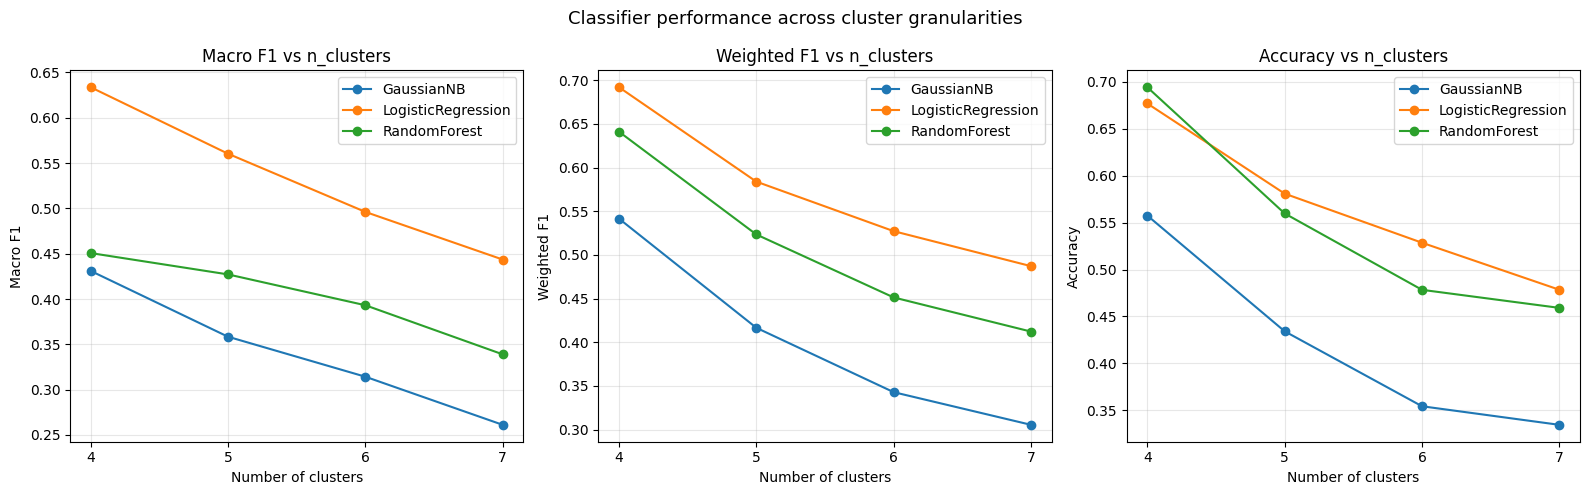

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('macro_f1', 'Macro F1'), ('weighted_f1', 'Weighted F1'), ('accuracy', 'Accuracy')]

for ax, (metric, label) in zip(axes, metrics):
    for model_name in models:
        subset = results_df[results_df['model'] == model_name]
        ax.plot(subset['n_clusters'], subset[metric], marker='o', label=model_name)
    ax.set_xlabel('Number of clusters')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs n_clusters')
    ax.set_xticks(list(CLUSTER_RANGE))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Classifier performance across cluster granularities', fontsize=13)
plt.tight_layout()
plt.show()

### Pivot table — macro F1 at a glance

In [22]:
pivot = results_df.pivot(index='n_clusters', columns='model', values='macro_f1').round(3)
pivot.index.name = 'n_clusters'
print("Macro F1 (mean, 5-fold CV):")
pivot

Macro F1 (mean, 5-fold CV):


model,GaussianNB,LogisticRegression,RandomForest
n_clusters,,,
4,0.431,0.634,0.451
5,0.358,0.560,0.427
6,0.314,0.496,0.393
7,0.261,0.444,0.339


### Inspect cluster memberships for a chosen n_clusters

Change `INSPECT_N` to any value in `CLUSTER_RANGE` to see what's in each cluster.

In [1]:
INSPECT_N = 4  # change this

print(f"Cluster memberships for n_clusters={INSPECT_N}:")
for cluster_id, grp in memberships[INSPECT_N].groupby('cluster'):
    print(f"  {cluster_id}: {grp['AA'].tolist()}")

Cluster memberships for n_clusters=4:


NameError: name 'memberships' is not defined

### Confusion matrix for a chosen n_clusters + model

Set `BEST_N` and `BEST_MODEL_NAME` based on what the summary plot shows.

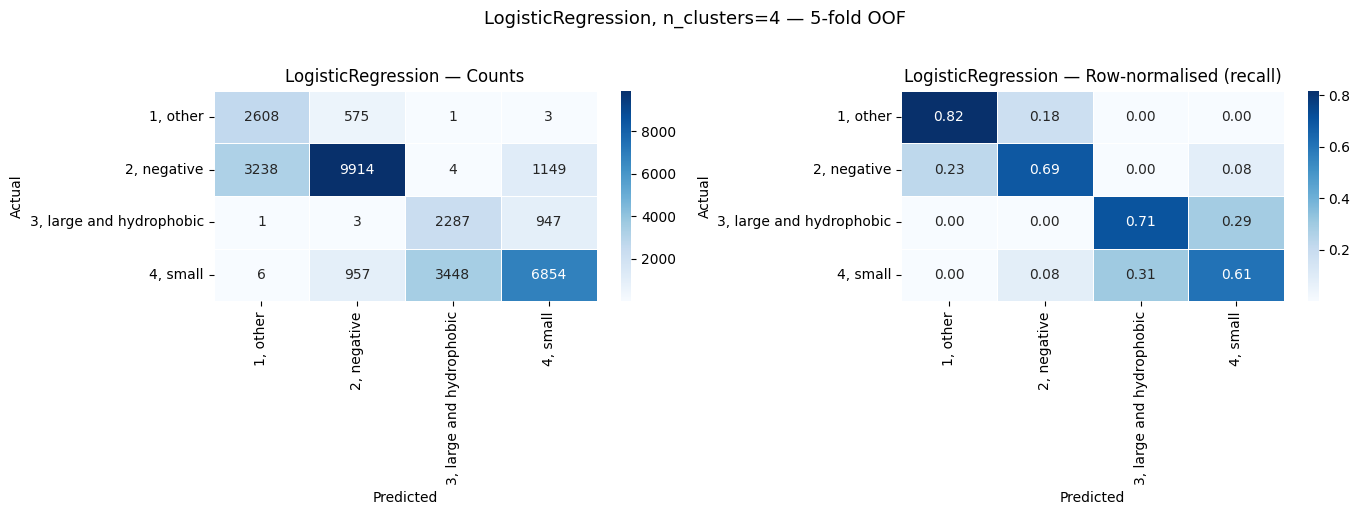

                          precision    recall  f1-score   support

                1, other       0.45      0.82      0.58      3187
             2, negative       0.87      0.69      0.77     14305
3, large and hydrophobic       0.40      0.71      0.51      3238
                4, small       0.77      0.61      0.68     11265

                accuracy                           0.68     31995
               macro avg       0.62      0.71      0.63     31995
            weighted avg       0.74      0.68      0.69     31995



In [24]:
BEST_N = 4              # change to the n_clusters you want to inspect
BEST_MODEL_NAME = 'LogisticRegression'  # or 'LogisticRegression'

raw_labels = fcluster(linkage_matrix, BEST_N, criterion='maxclust')
label_lookup = LABEL_MAP.get(BEST_N, {})
aa_to_cluster = {
    aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
    for i, aa in enumerate(amino_acids)
}

features = features_base.copy()
features['cluster_label'] = features['amino_acid'].map(aa_to_cluster)

X = features[feature_cols].values
y = features['cluster_label'].values
mask = ~np.isnan(X).any(axis=1)
X_clean, y_clean = X[mask], y[mask]

best_model = models[BEST_MODEL_NAME]
y_pred = cross_val_predict(best_model, X_clean, y_clean, cv=kf)

cluster_order = sorted(set(y_clean))
cm_counts = confusion_matrix(y_clean, y_pred, labels=cluster_order)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Counts', 'Row-normalised (recall)'],
    ['d', '.2f'],
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=cluster_order, yticklabels=cluster_order,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{BEST_MODEL_NAME} — {title}')

plt.suptitle(f'{BEST_MODEL_NAME}, n_clusters={BEST_N} — 5-fold OOF', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_clean, y_pred, labels=cluster_order, target_names=cluster_order))

### Null control — random control traces vs. shuffled-feature baseline

In [35]:
TEST_N          = 5
TEST_MODEL_NAME = 'RandomForest'

# ── Cluster mapping ───────────────────────────────────────────────────────
raw_labels_test = fcluster(linkage_matrix, TEST_N, criterion='maxclust')
label_lookup_test = LABEL_MAP.get(TEST_N, {})
aa_to_cluster_test = {
    aa: label_lookup_test.get(int(raw_labels_test[i]), f'cluster_{raw_labels_test[i]}')
    for i, aa in enumerate(amino_acids)
}

# ── Fit on training traces ────────────────────────────────────────────────
train_df = features_base.copy()
train_df['cluster_label'] = train_df['amino_acid'].map(aa_to_cluster_test)

X_train = train_df[feature_cols].values
y_train = train_df['cluster_label'].values
mask = ~np.isnan(X_train).any(axis=1)
X_train, y_train = X_train[mask], y_train[mask]

test_model = models[TEST_MODEL_NAME]
test_model.fit(X_train, y_train)

# ── Predict on random control traces ─────────────────────────────────────
test_base = pd.read_csv('../data/randomcontrol_feature_by_cluster.csv')
test_base['cluster_label'] = test_base['amino_acid'].map(aa_to_cluster_test)

X_test = test_base[feature_cols].values
y_test = test_base['cluster_label'].values
mask = ~np.isnan(X_test).any(axis=1)
X_test, y_test = X_test[mask], y_test[mask]

y_pred_test = test_model.predict(X_test)

# ── Null baseline: shuffle features to break signal ───────────────────────
rng = np.random.default_rng(42)
X_null = np.column_stack([rng.permutation(X_test[:, j]) for j in range(X_test.shape[1])])
y_pred_null = test_model.predict(X_null)

# ── Comparison ────────────────────────────────────────────────────────────
cluster_order = sorted(set(y_test))
real_acc = (y_pred_test == y_test).mean()
null_acc = (y_pred_null == y_test).mean()

print(f"Random control accuracy : {real_acc:.3f}")
print(f"Null (shuffled) accuracy: {null_acc:.3f}")
print()

print("── Random control ──")
print(classification_report(y_test, y_pred_test, labels=cluster_order, target_names=cluster_order))
print("── Null baseline ──")
print(classification_report(y_test, y_pred_null, labels=cluster_order, target_names=cluster_order))

Random control accuracy : 0.477
Null (shuffled) accuracy: 0.280

── Random control ──
                                       precision    recall  f1-score   support

                          1, negative       0.46      0.24      0.31      3165
                   2, polar and small       0.43      0.33      0.37      8049
                             3, small       0.46      0.30      0.37      6493
                          4, positive       0.28      0.19      0.23      3200
5, large and nonpolar(with one polar)       0.52      0.84      0.64     11091

                             accuracy                           0.48     31998
                            macro avg       0.43      0.38      0.38     31998
                         weighted avg       0.46      0.48      0.44     31998

── Null baseline ──
                                       precision    recall  f1-score   support

                          1, negative       0.10      0.14      0.12      3165
                   2,